# Uppgift 6.35

En konsolbalk vilandes på ett rullstöd som utsätts för en förskjutning

```mtm026``` är en fil med lite olika hjälpfunktioner som vi kommer använda i kursen, finns på Canvas att ladda ner. Kommer också finnas tillgänglig på tentan.

In [31]:
# import sympy as sp
from mtm026 import *

EI, L, x, Δ = sp.symbols("EI, L, x, Δ")
# display(EI, L, x, Δ)

### Definiera differentialekvationen

In [32]:
q = 0 # ingen fördelad last 
w = sp.Function('w')(x) # => Definierar en funktion w(x)

# (EI*w'')'' = q
ode = sp.Eq( sp.diff(EI*sp.diff(w, x, 2), x, 2), q)
display(ode)

Eq(EI*Derivative(w(x), (x, 4)), 0)

In [33]:

# Ta fram den allmänna lösningen till diffekvationen
w = sp.dsolve(ode, w).rhs
displayvar("w(x)", w)

<IPython.core.display.Math object>

## Randvillkor

Man använder funktionen `subs` för att substituera variabler, exemeplvis för att evaluera ett uttryck vid en viss koordinat som $w(L)$ => `w.subs(x, L)`

In [34]:
# Definiera lite hjälpfunktioner - gör det enkelt att definiera randvillkor
wprim = w.diff(x)   # w'
wbis = w.diff(x, 2) # w''
M = -EI*wbis


# Skapa ekvationer med sp.Eq( VL, HL )
# Använd subs för att evaluera ett uttryck vid en viss koordinat
RV1 = sp.Eq( w.subs(x, 0), 0)     # w(0) = 0
RV2 = sp.Eq( wprim.subs(x, 0), 0) # w'(0) = 0
RV3 = sp.Eq( w.subs(x, L), -Δ)    # w(L) = -Δ 
RV4 = sp.Eq (M.subs(x, L), 0)     # M(L)  = 0

display(RV1, RV2, RV3, RV4)

Eq(C1, 0)

Eq(C2, 0)

Eq(C1 + C2*L + C3*L**2 + C4*L**3, -Δ)

Eq(-2*EI*(C3 + 3*C4*L), 0)

## Lös ut integrationkonstanterna

In [35]:
ekvationer = [RV1, RV2, RV3, RV4]
obekanta = sp.symbols("C1 C2 C3 C4")
sol = sp.solve(ekvationer, obekanta)
displayvar("sol", sol)

<IPython.core.display.Math object>

In [36]:
# Använd subs igen för att substituera alla variabler i uttrycket w (C1-C4) med 
# motsvarande variabler i sol
w = w.subs(sol) # ger oss slutligt resultat på w
displayvar("w(x)", w)

M = M.subs(sol) # ger oss slutligt resultat på M
displayvar("M(x)", sp.simplify(M))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

Text(0.5, 1.0, 'Böjmoment [Nm]')

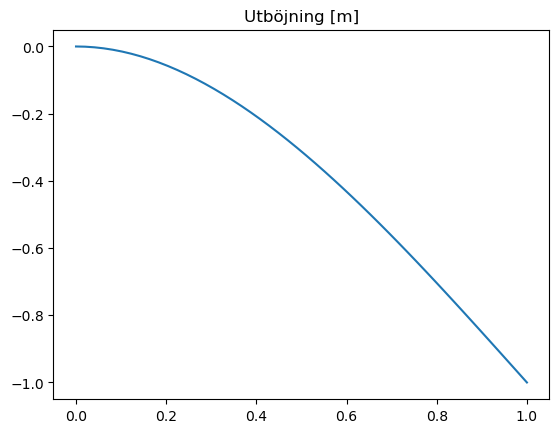

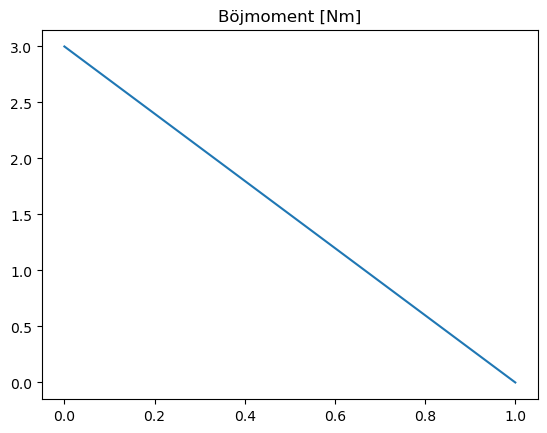

In [46]:
from matplotlib import pyplot as plt


w_ = sp.lambdify([x, EI, L, Δ], w, 'numpy')
M_ = sp.lambdify([x, EI, L, Δ], M, 'numpy')
x_ = np.linspace(0, 1)
M_(0, 1, 1, 1)
plt.plot(x_, w_(x_, 1, 1, 1))
plt.title("Utböjning [m]")
plt.figure()
plt.plot(x_, M_(x_, 1, 1, 1))
plt.title("Böjmoment [Nm]")